The reception is approaching! With your help, Alfred is now nearly finished with the preparations.

But now there's a problem: the Batmobile has disappeared. Alfred needs to find a replacement, and find it quickly.

Fortunately, a few biopics have been done on Bruce Wayne's life, so maybe Alfred could get a car left behind on one of the movie set, and re-engineer it up to modern standards, which certainly would include a full self-driving option.

But this could be anywhere in the filming locations around the world - which could be numerous.

So Alfred wants your help. Could you build an agent able to solve this task?

👉 Find all Batman filming locations in the world, calculate the time to transfer via a cargo plane to there, and represent them on a map, with a color varying by a cargo plane transfer time. Also represent some supercar factories with the same cargo plane transfer time.

Let's build this!

In [4]:
!pip install plotly geopandas shapely kaleido

  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached kaleido-1.2.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached narwhals-2.18.1-py3-none-any.whl.metadata (14 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (5.9 kB)
  Using cached pyproj-3.7.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (31 kB)
  Using cached choreographer-1.2.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached logistro-2.0.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytest_timeout-2.4.0-py3-none-any.whl.metadata (20 kB)
  Using cached simplejson-3.20.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.4 kB)
  Using cached pytest-9.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached plotl

In [5]:
!pip install 'smolagents[litellm]'

  Using cached litellm-1.83.2-py3-none-any.whl.metadata (30 kB)
  Using cached aiohttp-3.13.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached fastuuid-0.14.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (1.1 kB)
  Using cached importlib_metadata-8.5.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached jsonschema-4.23.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached openai-2.30.0-py3-none-any.whl.metadata (29 kB)
  Using cached python_dotenv-1.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached tiktoken-0.12.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.7 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached regex-2026.4.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 774.5 kB/s  0:00:20m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 748.9 kB/s  0:00:01 eta 0:00:01
   ━━━━━━━

In [6]:
import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami

load_dotenv(dotenv_path=".env", override=True)
token = os.environ.get("HF_TOKEN")

# Validate before logging in
try:
    login(token=token, add_to_git_credential=False)
    user = whoami()
    print(f"✅ Logged in as: {user['name']}")
except Exception as e:
    print(f"❌ Login failed: {e}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in as: zaidalissa


In [7]:
# We first make a tool to get the cargo plane transfer time.
import math
from typing import Optional, Tuple

from smolagents import tool


@tool
def calculate_cargo_travel_time(
    origin_coords: Tuple[float, float],
    destination_coords: Tuple[float, float],
    cruising_speed_kmh: Optional[float] = 750.0,  # Average speed for cargo planes
) -> float:
    """
    Calculate the travel time for a cargo plane between two points on Earth using great-circle distance.

    Args:
        origin_coords: Tuple of (latitude, longitude) for the starting point
        destination_coords: Tuple of (latitude, longitude) for the destination
        cruising_speed_kmh: Optional cruising speed in km/h (defaults to 750 km/h for typical cargo planes)

    Returns:
        float: The estimated travel time in hours

    Example:
        >>> # Chicago (41.8781° N, 87.6298° W) to Sydney (33.8688° S, 151.2093° E)
        >>> result = calculate_cargo_travel_time((41.8781, -87.6298), (-33.8688, 151.2093))
    """
    def to_radians(degrees: float) -> float:
        return degrees * (math.pi / 180)

    # Extract coordinates
    lat1, lon1 = map(to_radians, origin_coords)
    lat2, lon2 = map(to_radians, destination_coords)

    # Earth's radius in kilometers
    EARTH_RADIUS_KM = 6371.0

    # Calculate great-circle distance using the haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    c = 2 * math.asin(math.sqrt(a))
    distance = EARTH_RADIUS_KM * c

    # Add 10% to account for non-direct routes and air traffic controls
    actual_distance = distance * 1.1

    # Calculate flight time
    # Add 1 hour for takeoff and landing procedures
    flight_time = (actual_distance / cruising_speed_kmh) + 1.0

    # Format the results
    return round(flight_time, 2)


print(calculate_cargo_travel_time((41.8781, -87.6298), (-33.8688, 151.2093)))

22.82


For the model provider, we use Together AI, one of the new inference providers on the Hub!

Regarding the GoogleSearchTool: this requires either having setup env variable SERPAPI_API_KEY and passing provider="serpapi" or having SERPER_API_KEY and passing provider=serper.

If you don't have any Serp API provider setup, you can use WebSearchTool but beware that it has a rate limit.

In [49]:
import os
from PIL import Image
from smolagents import CodeAgent, GoogleSearchTool, InferenceClientModel, VisitWebpageTool


model = InferenceClientModel(
    model_id="Qwen/Qwen3-Coder-Next-FP8",  # code-specialized, available on Together serverless
    provider="together"
)

We can start with creating a baseline, simple agent to give us a simple report.

In [50]:
task = """Find all Batman filming locations in the world, calculate the time to transfer via cargo plane to here (we're in Gotham, 40.7128° N, 74.0060° W), and return them to me as a pandas dataframe.
Also give me some supercar factories with the same cargo plane transfer time."""

In [54]:
import os
from dotenv import load_dotenv
from langchain_community.agent_toolkits.load_tools import load_tools
from smolagents import CodeAgent, InferenceClientModel, Tool

load_dotenv(dotenv_path=".env", override=True)
os.environ.get("SERPAPI_API_KEY")
agent = CodeAgent(
    model=model,
    tools=[GoogleSearchTool(), VisitWebpageTool(), calculate_cargo_travel_time],
    additional_authorized_imports=["pandas"],
    max_steps=20,
)

In [55]:
agent

In [56]:
result = agent.run(task)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find all Batman filming locations in the world, calculate the time to transfer via cargo plane to here (we're   │
│ in Gotham, 40.7128° N, 74.0060° W), and return them to me as a pandas dataframe.                                │
│ Also give me some supercar factories with the same cargo plane transfer time.                                   │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Coder-Next-FP8 ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  batman_locations = web_search("Batman movie filming locations worldwide", filter_year=None)                      
  print(batman_locations)                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results
0. [The Batman | Film Locations](https://movie-locations.com/movies/b/The-Batman-2022-2.php)
Source: The Worldwide Guide To Movie Locations

Film locations for The Batman (2022) in Liverpool, London, Glasgow and Chicago.

1. [The Batman (2022) - Filming & production](https://www.imdb.com/title/tt1877830/locations/)
Source: IMDb

Filming locations ; Necropolis Cemetery, Glasgow, Scotland, UK. (Batman and Selina leaving the cemetery) · 88 ; St.
George's Hall, Liverpool, England, UK. ( ...

2. [Category:Film Locations | Batman Wiki - Fandom](https://batman.fandom.com/wiki/Category:Film_Locations)
Source: Batman Wiki | Fandom

A · Arctic World · Arkham Asylum (Nolanverse) · Arkham Asylum (Schumacherverse) · Arkham State Hospital ...

3. [Batman Begins Filming Locations: Complete Guide to 
...](https://giggster.com/guide/movie-location/where-was-batman-begins-filmed)
Source: Giggster

Discover all Batman Begins filming locations from Chicago's Gotham City to Iceland's Himalayan scenes. Explore 
Wayne Manor, Arkham Asylum & UK shooting ...

4. [What are the film locations of Batman 
movies?](https://www.facebook.com/groups/3164534807204454/posts/3749390682052194/)
Source: Facebook · Film Locations - Then and Now

Batman movie locations, if you want to find out where all the Batman movies were filmed have a look at this app: 
http://apps.facebook.com ...

5. [12 Batman Movie Locations You Can 
Visit!](https://www.travelandleisureasia.com/sea/destinations/batman-movie-locations-you-can-visit/)
Date published: Jan 10, 2023
Source: Travel and Leisure Asia

Most of the filming of Batman movies is done in the Warner Bros studios and across the US, including New York and 
Pittsburgh. You will notice ...

6. [*SNEAKING* Onto The Batman (Filming Locations)](https://www.youtube.com/watch?v=UFQ_eL_iSxI)
Source: YouTube · Manuel Boza

I snuck into the Batman filming locations and also visited the some of the most iconic Batman movie locations.

7. [The Filming Locations of The Batman : 
r/Tartaria](https://www.reddit.com/r/Tartaria/comments/tsd5zf/the_filming_locations_of_the_batman/)
Source: Reddit · r/Tartaria

r/batman - The Batman movie filming location // Thompson Center Downtown Chicago. 3. 8. 6. PRODUCTION: Glasgow 
Necropolis - "The Batman ...

8. [Where was The Batman filmed? ALL the Filming Locations 
...](https://www.atlasofwonders.com/2022/04/where-was-the-batman-filmed.html)
Source: Atlas of Wonders

Guide to the all the filming locations of The Batman - The 2022 movie with Robert Pattison filmed in Chicago and 
The UK - The City and the Wayne House.

Out: None

[Step 1: Duration 4.52 seconds| Input tokens: 2,323 | Output tokens: 115]

...

[Step 5: Duration 12.63 seconds| Input tokens: 38,017 | Output tokens: 1,941]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 6 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Return the final dataframe                                                                                     
  final_answer(all_locations_df)                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer:                                 Location Name                  City  Latitude  \
0             Chicago Board of Trade Building               Chicago   41.8833   
1   Thompson Center (James R Thompson Center)               Chicago   41.8828   
2                   Chicago (La Salle Street)               Chicago   41.8818   
3                          Glasgow Necropolis               Glasgow   55.8580   
4                           Hartwood Hospital                Shotts   55.7917   
5                            Anfield Cemetery             Liverpool   53.4267   
6                            St George's Hall             Liverpool   53.3950   
7                        Royal Liver Building             Liverpool   53.4080   
8                              Morgan Factory               Malvern   52.1167   
9                              Jaguar Factory              Coventry   52.3700   
10                       Aston Martin Factory                gaydon   52.1042   
11                 Cardington Airship Hangars          Bedfordshire   52.0583   
12                            Mentmore Towers       Buckinghamshire   51.8000   
13                 Cardington Airship Hangars          Bedfordshire   52.0583   
14                         Shepperton Studios                Surrey   51.3833   
15                         Dunsfold Aerodrome                Surrey   51.2333   
16                  McLaren Production Centre                Woking   51.3333   
17                        Rolls-Royce Factory              Goodwood   50.8167   
18                        St Pancras Chambers                London   51.5308   
19                          Farmiloe Building                London   51.5286   
20                           Lethaby Building                London   51.5147   
21                           Millennium Mills                London   51.5167   
22                                   O2 Arena                London   51.5033   
23                             Coalhouse Fort                 Essex   51.4833   
24                         Koenigsegg Factory             Angleholm   57.4167   
25                            Bugatti Factory              Molsheim   48.7000   
26                                AMG Factory          Affalterbach   48.8233   
27                       Mercedes-AMG Factory          Affalterbach   48.8233   
28                            Porsche Factory          Zuffenhausen   48.7797   
29                              BMW M Factory              Garching   48.3333   
30                             Pagani Factory                Modena   44.6472   
31                            Ferrari Factory             Maranello   44.6333   
32                        Lamborghini Factory  Sant'Agata Bolognese   44.6333   

    Longitude                     Type  Travel Time (hours)  
0    -87.6361  Batman Filming Location                 1.53  
1    -87.6272  Batman Filming Location                 1.53  
2    -87.6231  Batman Filming Location                 1.53  
3     -4.2580  Batman Filming Location                 6.91  
4     -3.7553  Batman Filming Location                 6.95  
5     -2.9583  Batman Filming Location                 7.10  
6     -2.9858  Batman Filming Location                 7.10  
7     -2.9780  Batman Filming Location                 7.10  
8     -2.3333         Supercar Factory                 7.21  
9     -1.4700         Supercar Factory                 7.27  
10    -1.6053         Supercar Factory                 7.27  
11    -0.4833  Batman Filming Location                 7.37  
12    -0.5833  Batman Filming Location                 7.37  
13    -0.4833  Batman Filming Location                 7.37  
14    -0.5833  Batman Filming Location                 7.39  
15    -0.6167  Batman Filming Location                 7.40  
16    -0.5500         Supercar Factory                 7.40  
17    -0.7333         Supercar Factory                 7.41  
18    -0.1342  Batman Filming Location               

[Step 6: Duration 1.80 seconds| Input tokens: 55,326 | Output tokens: 2,133]

In [57]:
result

,Location Name,City,Latitude,Longitude,Type,Travel Time (hours)
0,Chicago Board of Trade Building,Chicago,41.8833,-87.6361,Batman Filming Location,1.53
1,Thompson Center (James R Thompson Center),Chicago,41.8828,-87.6272,Batman Filming Location,1.53
2,Chicago (La Salle Street),Chicago,41.8818,-87.6231,Batman Filming Location,1.53
3,Glasgow Necropolis,Glasgow,55.8580,-4.2580,Batman Filming Location,6.91
4,Hartwood Hospital,Shotts,55.7917,-3.7553,Batman Filming Location,6.95
5,Anfield Cemetery,Liverpool,53.4267,-2.9583,Batman Filming Location,7.10
6,St George's Hall,Liverpool,53.3950,-2.9858,Batman Filming Location,7.10
7,Royal Liver Building,Liverpool,53.4080,-2.9780,Batman Filming Location,7.10
8,Morgan Factory,Malvern,52.1167,-2.3333,Supercar Factory,7.21
9,Jaguar Factory,Coventry,52.3700,-1.4700,Supercar Factory,7.27


We could already improve this a bit by throwing in some dedicated planning steps, and adding more prompting.

In [58]:
agent.planning_interval = 4

detailed_report = agent.run(f"""
You're an expert analyst. You make comprehensive reports after visiting many websites.
Don't hesitate to search for many queries at once in a for loop.
For each data point that you find, visit the source url to confirm numbers.

{task}
""")

print(detailed_report)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You're an expert analyst. You make comprehensive reports after visiting many websites.                          │
│ Don't hesitate to search for many queries at once in a for loop.                                                │
│ For each data point that you find, visit the source url to confirm numbers.                                     │
│                                                                                                                 │
│ Find all Batman filming locations in the world, calculate the time to transfer via cargo plane to here (we're   │
│ in Gotham, 40.7128° N, 74.0060° W), and return them to me as a pandas dataframe.                                │
│ Also give me some supercar factories with the same cargo plane transfer time.                                   │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Coder-Next-FP8 ──────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────── Initial plan ───────────────────────────────────────────────────
Here are the facts I know and the plan of action that I will follow to solve the task:
```
### 1. Facts survey

#### 1.1. Facts given in the task
- Current location: Gotham, coordinates (40.7128° N, 74.0060° W)
- Goal: Find all Batman filming locations worldwide
- Goal: Find supercar factories worldwide
- Goal: Calculate cargo plane transfer time from each location to Gotham
- Use pandas dataframe for final output
- Must verify each data point by visiting source URLs

#### 1.2. Facts to look up
- List of all Batman (film/TV) filming locations globally — with precise coordinates for each location
  - Sources: Wikipedia (e.g., “List of Batman filming locations”, “Batman (franchise)” page), IMDb “Filming 
locations” sections for each Batman production, official studio press releases, reputable entertainment databases 
(e.g., Behind The Screens, Production List)
- Coordinates (latitude, longitude) for each Batman filming location — if not given, need to geocode using official
addresses or city + venue name
- List of supercar manufacturers and their factory locations — with precise coordinates
  - Sources: Wikipedia (“List of supercar manufacturers”, “Supercar” page), manufacturer websites, automotive 
databases (e.g., Supercar Drivers, Top Gear, Car and Driver)
- Confirm that “Batman” includes all major film/TV iterations: e.g., Tim Burton/Joel Schumacher films, Nolan’s Dark
Knight trilogy,DC Extended Universe (Zack Snyder), Matt Reeves’ *The Batman*, animated series (if live-action 
filming occurred elsewhere), etc. — need scope clarification, but default to all major live-action and animated 
*filming* locations (not voice recording studios)
- Cargo plane cruising speed: assumed default 750 km/h (per `calculate_cargo_travel_time` docstring), but verify if
anyBatman filming involved military cargo aircraft (unlikely; standard cargo plane speed applies)
- Need to ensure all filming locations are *distinct* from supercar factory locations (though overlap possible — 
e.g., if a Batman scene filmed outside a Ferrari factory — but those are rare and still need separate listing)

#### 1.3. Facts to derive
- Great-circle distance from each Batman filming location to Gotham (40.7128° N, 74.0060° W)
- Great-circle distance from each supercar factory location to Gotham
- Cargo travel time using `calculate_cargo_travel_time` for both sets (Batman filming locations and supercar 
factories)
- Compile derived data into pandas DataFrame with columns: `["Type", "Location Name", "Address/City", "Latitude", 
"Longitude", "Distance_km", "Travel_Time_hours"]`
- Possibly filter supercar factories to only those with travel time comparable to Batman filming locations — but 
task says “also give me some supercar factories with the same cargo plane transfer time”, implying any supercar 
factory; however, likely need to report all or highlight notable ones. We'll interpret as: list all supercar 
factories, compute travel times, include them in dataframe (maybe flagged by type).

### 2. Plan
1. Search for comprehensive list of Batman filming locations globally (include major film/TV iterations).
2. For each result, visit relevant URLs to extract precise filming location details (city, venue, country) and 
geocode to (lat, lon).
3. Search for global list of supercar manufacturers and their factory locations.
4. For each supercar factory, extract city/coordinates; verify via manufacturer site or reputable source.
5. For both Batman filming locations and supercar factories, compute great-circle distance and travel time to 
Gotham (40.7128° N, 74.0060° W) using `calculate_cargo_travel_time`.
6. Construct pandas DataFrame with columns: Type (Batman filming location / supercar factory), Location Name, 
City/Country, Coordinates, Distance (km), Travel Time (hours).
7. Return the final DataFrame as output.


```

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Search for Batman filming locations globally                                                                   
  batman_locations_queries = [                                                                                     
      "Batman filming locations worldwide list",                                                                   
      "Dark Knight trilogy filming locations",                                                                     
      "Batman (2022) The Batman filming locations",                                                                
      "Batman Returns filming locations",                                                                          
      "Batman Forever filming locations",                                                                          
      "Batman & Robin 1997 filming locations",                                                                     
      "Tim Burton Batman filming locations"                                                                        
  ]                                                                                                                
                                                                                                                   
  batman_locations_results = []                                                                                    
  for query in batman_locations_queries:                                                                           
      results = web_search(query, filter_year=None)                                                                
      batman_locations_results.append((query, results))                                                            
      print(f"Query: {query}")                                                                                     
      print(f"Results: {results[:500]}...")  # Print first 500 chars to avoid too much output                      
      print("---")                                                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Query: Batman filming locations worldwide list
Results: ## Search Results
0. [Category:Film Locations | Batman Wiki - Fandom](https://batman.fandom.com/wiki/Category:Film_Locations)
Source: Batman Wiki | Fandom

A · Arctic World · Arkham Asylum (Nolanverse) · Arkham Asylum (Schumacherverse) · Arkham State Hospital ...

1. [The Batman | Film Locations](https://movie-locations.com/movies/b/The-Batman-2022-2.php)
Source: The Worldwide Guide To Movie Locations

The Batman | 2022 · Merseyside · London · Scotland · Bedfordshire · Hertfordshire · Essex · Su...
---
Query: Dark Knight trilogy filming locations
Results: ## Search Results
0. [The Dark Knight | 2008](https://movie-locations.com/movies/d/Dark-Knight.php)
Source: The Worldwide Guide To Movie Locations

Discover where The Dark Knight (2008) was filmed around Chicago, as well as in London and Bedfordshire in the UK, 
and briefly in Hong Kong.

1. [r/batman - The Dark Knight was released 15 years ago 
...](https://www.reddit.com/r/batman/comments/1537lrk/the_dark_knight_was_released_15_years_ago_today/)
Source: Reddit · r/batman

As far as I know the da...
---
Query: Batman (2022) The Batman filming locations
Results: ## Search Results
0. [The Batman | Film Locations](https://movie-locations.com/movies/b/The-Batman-2022-2.php)
Source: The Worldwide Guide To Movie Locations

Film locations for The Batman (2022) in Liverpool, London, Glasgow and Chicago.

1. [The Batman (2022) - Filming & production](https://www.imdb.com/title/tt1877830/locations/)
Source: IMDb

Filming locations ; Necropolis Cemetery, Glasgow, Scotland, UK. (Batman and Selina leaving the cemetery) · 88 ; St.
George's Hall, Liverpool, England, ...
---
Query: Batman Returns filming locations
Results: ## Search Results
0. [Batman Returns (1992) - Filming & production](https://www.imdb.com/title/tt0103776/locations/)
Source: IMDb

Filming locations: Stage 12, Universal Studios - 100 Universal City Plaza, Universal City, California, USA 
(Penguin's lair, demolished in 2020)

1. [Batman Returns | Film Locations](https://movie-locations.com/movies/b/Batman-Returns.php)
Source: The Worldwide Guide To Movie Locations

The streets of 'Gotham City' use the old Brownstone Street and Hennessy Street (wh...
---
Query: Batman Forever filming locations
Results: ## Search Results
0. [Batman Forever film location](https://movie-locations.com/movies/b/Batman-Forever.php)
Source: The Worldwide Guide To Movie Locations

Film locations for Batman Forever (1995), In New York and Los Angeles: Webb Institute of Naval Architecture, Welwyn
Preserve, Glen Cove, Long Island ('Wayne ...

1. [Batman Forever (1995) - Filming & production](https://www.imdb.com/title/tt0112462/locations/)
Source: IMDb

Filming locations: Alcatraz Island, San Francisco Bay, California, U...
---
Query: Batman & Robin 1997 filming locations
Results: ## Search Results
0. [Batman & Robin (1997) - Filming & production](https://www.imdb.com/title/tt0118688/locations/)
Source: IMDb

Filming locations · Courthouse Square, Backlot, Universal Studios - 100 Universal City Plaza, Universal City, 
California, USA · Warner Brothers Burbank Studios - ...

1. [Film locations for Batman And Robin (1997), in Los 
Angeles](https://movie-locations.com/movies/b/Batman-And-Robin.php)
Source: The Worldwide Guide To Movie Locations

Batman and Robin filming locati...
---
Query: Tim Burton Batman filming locations
Results: ## Search Results
0. [Film locations for Tim Burton's Batman (1989), in London, 
...](https://movie-locations.com/movies/b/Batman-1989.php)
Source: The Worldwide Guide To Movie Locations

Discover the film locations for Tim Burton's Batman in London and Southeast England: Knebworth House, Knebworth, 
Hertfordshire ('Wayne Manor' exterior); ...

1. [Batman (1989 film)](https://en.wikipedia.org/wiki/Batman_(1989_film))
Source: Wikipedia

Batman is a 1989 superhero film directed by Tim Burton and wri...
---

Out: ## Search Results
0. [Film locations for T

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Final DataFrame with all locations sorted by travel time                                                       
  import pandas as pd                                                                                              
                                                                                                                   
  # Recreate the DataFrame with cleaner formatting                                                                 
  batman_locations = [                                                                                             
      ("Glasgow, Scotland", 55.864304, -4.254490, "The Batman 2022"),                                              
      ("Liverpool, England", 53.408371, -2.991573, "The Batman 2022"),                                             
      ("Chicago, Illinois, USA", 41.877895, -87.643623, "Multiple Batman films"),                                  
      ("Liverpool, UK - County Sessions House", 53.410164, -2.979004, "The Batman 2022"),                          
      ("Twin Anchors, Chicago", 41.9226, -87.6362, "The Dark Knight"),                                             
      ("Knebworth House, UK", 51.9897, -0.2542, "Batman 1989"),                                                    
      ("Hatfield House, UK", 51.7540, -0.2305, "Batman 1989"),                                                     
      ("Pinewood Studios, UK", 51.5300, -0.7000, "Batman 1989"),                                                   
      ("Mentmore Towers, UK", 51.6558, -0.3664, "Batman Begins Wayne Manor"),                                      
      ("Alcatraz Island, CA", 37.8267, -122.4233, "Batman Forever"),                                               
      ("New York City, NY", 40.7128, -74.0060, "Batman Forever"),                                                  
      ("Los Angeles, CA", 34.0522, -118.2437, "Batman Forever & Batman & Robin"),                                  
      ("Universal Studios, CA", 34.1381, -118.3365, "Batman Returns & Batman & Robin"),                            
      ("Baltimore, MD", 39.2904, -76.6122, "Gotham TV Series")                                                     
  ]                                                                                                                
                                                                                                                   
  supercar_factories = [                                                                                           
      ("Ferrari Factory, Maranello, Italy", 44.7577, 10.8474, "Ferrari"),                                          
      ("Lamborghini Factory, Sant'Agata Bolognese, Italy", 44.6253, 11.2151, "Lamborghini"),                       
      ("Porsche Factory, Zuffenhausen, Germany", 48.7917, 9.1936, "Porsche"[38;2;248;2

Execution logs:
=== FINAL COMPREHENSIVE REPORT ===

Batman Filming Locations & Supercar Factories near Gotham
Gotham Coordinates: 40.7128° N, 74.0060° W
Cargo Plane Cruising Speed: 750 km/h

Locations sorted by cargo plane travel time:
                       Type                                     Location Name   Latitude   Longitude              
Coordinates                             Info  Distance_km  Travel_Time_hours
0   Batman Filming Location                                 New York City, NY  40.712800  -74.006000   40.7128° N, 
74.0060° W                   Batman Forever         0.00               0.00
1   Batman Filming Location                                     Baltimore, MD  39.290400  -76.612200   39.2904° N, 
76.6122° W                 Gotham TV Series       272.55               0.36
2   Batman Filming Location                            Chicago, Illinois, USA  41.877895  -87.643623   41.8779° N, 
87.6436° W            Multiple Batman films      1145.43               1.53
3   Batman Filming Location                             Twin Anchors, Chicago  41.922600  -87.636200   41.9226° N, 
87.6362° W                  The Dark Knight      1145.00               1.53
4   Batman Filming Location                             Universal Studios, CA  34.138100 -118.336500  34.1381° N, 
118.3365° W  Batman Returns & Batman & Robin      3939.66               5.25
5   Batman Filming Location                                   Los Angeles, CA  34.052200 -118.243700  34.0522° N, 
118.2437° W  Batman Forever & Batman & Robin      3935.75               5.25
6   Batman Filming Location                               Alcatraz Island, CA  37.826700 -122.423300  37.8267° N, 
122.4233° W                   Batman Forever      4127.43               5.50
7   Batman Filming Location                                 Glasgow, Scotland  55.864304   -4.254490    55.8643° N,
4.2545° W                  The Batman 2022      5181.58               6.91
8   Batman Filming Location             Liverpool, UK - County Sessions House  53.410164   -2.979004    53.4102° N,
2.9790° W                  The Batman 2022      5324.58               7.10
9   Batman Filming Location                                Liverpool, England  53.408371   -2.991573    53.4084° N,
2.9916° W                  The Batman 2022      5323.83               7.10
10  Batman Filming Location                              Pinewood Studios, UK  51.530000   -0.700000    51.5300° N,
0.7000° W                      Batman 1989      5531.82               7.38
11  Batman Filming Location                               Knebworth House, UK  51.989700   -0.254200    51.9897° N,
0.2542° W                      Batman 1989      5545.29               7.39
12  Batman Filming Location                               Mentmore Towers, UK  51.655800   -0.366400    51.6558° N,
0.3664° W        Batman Begins Wayne Manor      5549.41               7.40
13         Supercar Factory             McLaren Technology Centre, Woking, UK  51.329700   -0.560300    51.3297° N,
0.5603° W                          McLaren      5547.94               7.40
14  Batman Filming Location                                Hatfield House, UK  51.754000   -0.230500    51.7540° N,
0.2305° W                      Batman 1989      5554.92               7.41
15         Supercar Factory             Koenigsegg Factory, Ängelholm, Sweden  56.550000   13.000000   56.5500° N, 
13.0000° E                       Koenigsegg      6174.04               8.23
16         Supercar Factory                 Bugatti Factory, Molsheim, France  48.633300    7.750000    48.6333° N,
7.7500° E                          Bugatti      6210.30               8.28
17         Supercar Factory            Porsche Factory, Zuffenhausen, Germany  48.791700    9.193600    48.7917° N,
9.1936° E                          Porsche      6298.49               8.40
18         Supercar Factory           Audi Sport Factory, Neckarsulm, Germany  49.140800   10.272500   49.1408° N, 
10.2725° E

Final answer:                        Type                                     Location Name  \
0   Batman Filming Location                                 New York City, NY   
1   Batman Filming Location                                     Baltimore, MD   
2   Batman Filming Location                            Chicago, Illinois, USA   
3   Batman Filming Location                             Twin Anchors, Chicago   
4   Batman Filming Location                             Universal Studios, CA   
5   Batman Filming Location                                   Los Angeles, CA   
6   Batman Filming Location                               Alcatraz Island, CA   
7   Batman Filming Location                                 Glasgow, Scotland   
8   Batman Filming Location             Liverpool, UK - County Sessions House   
9   Batman Filming Location                                Liverpool, England   
10  Batman Filming Location                              Pinewood Studios, UK   
11  Batman Filming Location                               Knebworth House, UK   
12  Batman Filming Location                               Mentmore Towers, UK   
13         Supercar Factory             McLaren Technology Centre, Woking, UK   
14  Batman Filming Location                                Hatfield House, UK   
15         Supercar Factory             Koenigsegg Factory, Ängelholm, Sweden   
16         Supercar Factory                 Bugatti Factory, Molsheim, France   
17         Supercar Factory            Porsche Factory, Zuffenhausen, Germany   
18         Supercar Factory           Audi Sport Factory, Neckarsulm, Germany   
19         Supercar Factory                 Ferrari Factory, Maranello, Italy   
20         Supercar Factory  Lamborghini Factory, Sant'Agata Bolognese, Italy   

     Latitude   Longitude              Coordinates  \
0   40.712800  -74.006000   40.7128° N, 74.0060° W   
1   39.290400  -76.612200   39.2904° N, 76.6122° W   
2   41.877895  -87.643623   41.8779° N, 87.6436° W   
3   41.922600  -87.636200   41.9226° N, 87.6362° W   
4   34.138100 -118.336500  34.1381° N, 118.3365° W   
5   34.052200 -118.243700  34.0522° N, 118.2437° W   
6   37.826700 -122.423300  37.8267° N, 122.4233° W   
7   55.864304   -4.254490    55.8643° N, 4.2545° W   
8   53.410164   -2.979004    53.4102° N, 2.9790° W   
9   53.408371   -2.991573    53.4084° N, 2.9916° W   
10  51.530000   -0.700000    51.5300° N, 0.7000° W   
11  51.989700   -0.254200    51.9897° N, 0.2542° W   
12  51.655800   -0.366400    51.6558° N, 0.3664° W   
13  51.329700   -0.560300    51.3297° N, 0.5603° W   
14  51.754000   -0.230500    51.7540° N, 0.2305° W   
15  56.550000   13.000000   56.5500° N, 13.0000° E   
16  48.633300    7.750000    48.6333° N, 7.7500° E   
17  48.791700    9.193600    48.7917° N, 9.1936° E   
18  49.140800   10.272500   49.1408° N, 10.2725° E   
19  44.757700   10.847400   44.7577° N, 10.8474° E   
20  44.625300   11.215100   44.6253° N, 11.2151° E   

                               Info  Distance_km  Travel_Time_hours  
0                    Batman Forever         0.00               0.00  
1                  Gotham TV Series       272.55               0.36  
2             Multiple Batman films      1145.43               1.53  
3                   The Dark Knight      1145.00               1.53  
4   Batman Returns & Batman & Robin      3939.66               5.25  
5   Batman Forever & Batman & Robin      3935.75               5.25  
6                    Batman Forever      4127.43               5.50  
7                   The Batman 2022      5181.58               6.91  
8                   The Batman 2022      5324.58               7.10  
9                   The Batman 2022      5323.83               7.10  
10                      Batman 1989      5531.82               7.38  
11                      Batman 1989      5545.29               7.39  
12        Batman Begins Wayne Manor      5549.41               7.40  
13                          McLare

[Step 7: Duration 13.13 seconds| Input tokens: 80,856 | Output tokens: 6,099]

                       Type                                     Location Name  \
0   Batman Filming Location                                 New York City, NY   
1   Batman Filming Location                                     Baltimore, MD   
2   Batman Filming Location                            Chicago, Illinois, USA   
3   Batman Filming Location                             Twin Anchors, Chicago   
4   Batman Filming Location                             Universal Studios, CA   
5   Batman Filming Location                                   Los Angeles, CA   
6   Batman Filming Location                               Alcatraz Island, CA   
7   Batman Filming Location                                 Glasgow, Scotland   
8   Batman Filming Location             Liverpool, UK - County Sessions House   
9   Batman Filming Location                                Liverpool, England   
10  Batman Filming Location                              Pinewood Studios, UK   
11  Batman Filming Location 

In [59]:
detailed_report

,Type,Location Name,Latitude,Longitude,Coordinates,Info,Distance_km,Travel_Time_hours
0,Batman Filming Location,"New York City, NY",40.712800,-74.006000,"40.7128° N, 74.0060° W",Batman Forever,0.00,0.00
1,Batman Filming Location,"Baltimore, MD",39.290400,-76.612200,"39.2904° N, 76.6122° W",Gotham TV Series,272.55,0.36
2,Batman Filming Location,"Chicago, Illinois, USA",41.877895,-87.643623,"41.8779° N, 87.6436° W",Multiple Batman films,1145.43,1.53
3,Batman Filming Location,"Twin Anchors, Chicago",41.922600,-87.636200,"41.9226° N, 87.6362° W",The Dark Knight,1145.00,1.53
4,Batman Filming Location,"Universal Studios, CA",34.138100,-118.336500,"34.1381° N, 118.3365° W",Batman Returns & Batman & Robin,3939.66,5.25
5,Batman Filming Location,"Los Angeles, CA",34.052200,-118.243700,"34.0522° N, 118.2437° W",Batman Forever & Batman & Robin,3935.75,5.25
6,Batman Filming Location,"Alcatraz Island, CA",37.826700,-122.423300,"37.8267° N, 122.4233° W",Batman Forever,4127.43,5.50
7,Batman Filming Location,"Glasgow, Scotland",55.864304,-4.254490,"55.8643° N, 4.2545° W",The Batman 2022,5181.58,6.91
8,Batman Filming Location,"Liverpool, UK - County Sessions House",53.410164,-2.979004,"53.4102° N, 2.9790° W",The Batman 2022,5324.58,7.10
9,Batman Filming Location,"Liverpool, England",53.408371,-2.991573,"53.4084° N, 2.9916° W",The Batman 2022,5323.83,7.10


Thanks to these quick changes, we obtained a much more concise report by simply providing our agent a detailed prompt, and giving it planning capabilities!

💸 But as you can see, the context window is quickly filling up. So if we ask our agent to combine the results of detailed search with another, it will be slower and quickly ramp up tokens and costs.

➡️ We need to improve the structure of our system.

## Splitting the task between two agents
Multi-agent structures allow to separate memories between different sub-tasks, with two great benefits:

Each agent is more focused on its core task, thus more performant
Separating memories reduces the count of input tokens at each step, thus reducing latency and cost.
Let's create a team with a dedicated web search agent, managed by another agent.

The manager agent should have plotting capabilities to redact its final report: so let us give it access to additional imports, including plotly, and geopandas + shapely for spatial plotting.



In [89]:
import os
from dotenv import load_dotenv
from langchain_community.agent_toolkits.load_tools import load_tools
from smolagents import CodeAgent, InferenceClientModel, Tool
from smolagents import ToolCallingAgent

load_dotenv(dotenv_path=".env", override=True)
os.environ.get("SERPAPI_API_KEY")

# model = InferenceClientModel(
#     "Qwen/Qwen3-Coder-Next-FP8", provider="together", max_tokens=8096
# )

# web_agent = CodeAgent(
#     model=model,
#     tools=[
#         GoogleSearchTool(provider="serpapi"),
#         VisitWebpageTool(),
#         calculate_cargo_travel_time,
#     ],
#     name="web_agent",
#     description="Browses the web to find information",
#     verbosity_level=0,
#     max_steps=10,
# )



web_agent = ToolCallingAgent(  # ← this accepts native tool calls
    model=InferenceClientModel(
        "Qwen/Qwen3-Coder-Next-FP8", provider="together", max_tokens=8096
    ),
    tools=[GoogleSearchTool(provider="serpapi"), VisitWebpageTool(), calculate_cargo_travel_time],
    name="web_agent",
    description="Browses the web to find information",
    verbosity_level=0,
    max_steps=10,
)

In [90]:
web_agent

The manager agent will need to do some mental heavy lifting.

So we give it the stronger model DeepSeek-R1, and add a planning_interval to the mix.

In [91]:
# Load env variables
import os
from dotenv import load_dotenv
import anthropic
import base64
import os
from PIL import Image
from io import BytesIO

load_dotenv(dotenv_path=".env", override=True)
c = anthropic.Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY"))

In [117]:
import anthropic
import base64
import os
from PIL import Image
from smolagents import CodeAgent, InferenceClientModel


def check_reasoning_and_plot(final_answer, agent_memory):
    client = c
    filepath = "saved_map.png"
    assert os.path.exists(filepath), "Make sure to save the plot under saved_map.png!"

    # Encode image to base64
    with open(filepath, "rb") as f:
        image_data = base64.standard_b64encode(f.read()).decode("utf-8")

    prompt = (
        f"Here is a user-given task and the agent steps: {agent_memory.get_succinct_steps()}. Now here is the plot that was made."
        "Please check that the reasoning process and plot are correct: do they correctly answer the given task?"
        "First list reasons why yes/no, then write your final decision: PASS in caps lock if it is satisfactory, FAIL if it is not."
        "Don't be harsh: if the plot mostly solves the task, it should pass."
        "To pass, a plot should be made using px.scatter_map and not any other method (scatter_map looks nicer)."
    )

    message = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=8096,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": "image/png",
                            "data": image_data,
                        },
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            }
        ],
    )

    output = message.content[0].text
    print("Feedback: ", output)
    if "FAIL" in output:
        raise Exception(output)
    return True


manager_agent = CodeAgent(
    model=InferenceClientModel("Qwen/Qwen2.5-Coder-32B-Instruct", max_tokens=8096),
    tools=[calculate_cargo_travel_time],
    managed_agents=[web_agent],
    additional_authorized_imports=[
        "geopandas",
        "plotly",
        "shapely",
        "json",
        "pandas",
        "numpy",
    ],
    planning_interval=5,
    verbosity_level=2,
    final_answer_checks=[check_reasoning_and_plot],
    max_steps=15,
)

In [118]:
manager_agent.agent_name

'CodeAgent'

In [119]:
manager_agent.visualize()

CodeAgent | Qwen/Qwen2.5-Coder-32B-Instruct
├── ✅ Authorized imports: ['geopandas', 'plotly', 'shapely', 'json', 'pandas', 'numpy']
├── 🛠️ Tools:
│   ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
│   ┃ Name                        ┃ Description                           ┃ Arguments                             ┃
│   ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   │ calculate_cargo_travel_time │ Calculate the travel time for a cargo │ origin_coords (`array`): Tuple of     │
│   │                             │ plane between two points on Earth     │ (latitude, longitude) for the         │
│   │                             │ using great-circle distance.          │ starting point                        │
│   │                             │                                       │ destination_coords (`array`): Tuple   │
│   │                             │                                       │ of (latitude, longitude) for the      │
│   │                             │                                       │ destination                           │
│   │                             │                                       │ cruising_speed_kmh (`number`):        │
│   │                             │                                       │ Optional cruising speed in km/h       │
│   │                             │                                       │ (defaults to 750 km/h for typical     │
│   │                             │                                       │ cargo planes)                         │
│   │ final_answer                │ Provides a final answer to the given  │ answer (`any`): The final answer to   │
│   │                             │ problem.                              │ the problem                           │
│   └─────────────────────────────┴───────────────────────────────────────┴───────────────────────────────────────┘
└── 🤖 Managed agents:
    └── web_agent | ToolCallingAgent | Qwen/Qwen3-Coder-Next-FP8
        ├── 📝 Description: Browses the web to find information
        └── 🛠️ Tools:
            ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
            ┃ Name                        ┃ Description                       ┃ Arguments                         ┃
            ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
            │ web_search                  │ Performs a google web search for  │ query (`string`): The search      │
            │                             │ your query then returns a string  │ query to perform.                 │
            │                             │ of the top search results.        │ filter_year (`integer`):          │
            │                             │                                   │ Optionally restrict results to a  │
            │                             │                                   │ certain year                      │
            │ visit_webpage               │ Visits a webpage at the given url │ url (`string`): The url of the    │
            │                             │ and reads its content as a        │ webpage to visit.                 │
            │                             │ markdown string. Use this to      │                                   │
            │                             │ browse webpages.                  │                                   │
            │ calculate_cargo_travel_time │ Calculate the travel time for a   │ origin_coords (`array`): Tuple of │
            │                             │ cargo plane between two points on │ (latitude, longitude) for the     │
            │                             │ Earth using great-circle          │ starting point                    │
            │                             │ distance.                         │ destin

In [120]:
manager_agent.run("""
Find all Batman filming locations in the world, calculate the time to transfer via cargo plane to here (we're in Gotham, 40.7128° N, 74.0060° W).
Also give me some supercar factories with the same cargo plane transfer time. You need at least 6 points in total.
Represent this as spatial map of the world, with the locations represented as scatter points with a color that depends on the travel time, and save it to saved_map.png!

Here's an example of how to plot and return a map:
import plotly.express as px
df = px.data.carshare()
fig = px.scatter_map(df, lat="centroid_lat", lon="centroid_lon", text="name", color="peak_hour", size=100,
     color_continuous_scale=px.colors.sequential.Magma, size_max=15, zoom=1)
fig.show()
fig.write_image("saved_image.png")
final_answer(fig)

Never try to process strings using code: when you have a string to read, just print it and you'll see it.
""")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find all Batman filming locations in the world, calculate the time to transfer via cargo plane to here (we're   │
│ in Gotham, 40.7128° N, 74.0060° W).                                                                             │
│ Also give me some supercar factories with the same cargo plane transfer time. You need at least 6 points in     │
│ total.                                                                                                          │
│ Represent this as spatial map of the world, with the locations represented as scatter points with a color that  │
│ depends on the travel time, and save it to saved_map.png!                                                       │
│                                                                                                                 │
│ Here's an example of how to plot and return a map:                                                              │
│ import plotly.express as px                                                                                     │
│ df = px.data.carshare()                                                                                         │
│ fig = px.scatter_map(df, lat="centroid_lat", lon="centroid_lon", text="name", color="peak_hour", size=100,      │
│      color_continuous_scale=px.colors.sequential.Magma, size_max=15, zoom=1)                                    │
│ fig.show()                                                                                                      │
│ fig.write_image("saved_image.png")                                                                              │
│ final_answer(fig)                                                                                               │
│                                                                                                                 │
│ Never try to process strings using code: when you have a string to read, just print it and you'll see it.       │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

────────────────────────────────────────────────── Initial plan ───────────────────────────────────────────────────
Here are the facts I know and the plan of action that I will follow to solve the task:
```
## 1. Facts Survey

### 1.1. Facts given in the task
- We are located in Gotham with coordinates: 40.7128° N, 74.0060° W.
- We need a minimum of 6 points in total (Batman filming locations + supercar factories).

### 1.2. Facts to look up
- Batman filming locations worldwide: 
    - **Source:** Websites like IMDb, official Warner Bros. productions pages, or filmography databases such as the
Hollywood Reporter.
- Supercar factories worldwide:
    - **Source:** Automotive manufacturing industry websites, automotive news sites, or specialized databases such 
as Supercar.net.
- Coordinates of Batman filming locations and supercar factories:
    - **Source:** Wikipedia articles on Batman films and their locations, Google Maps, or dedicated GPS databases.

### 1.3. Facts to derive
- Travel time from Gotham to each filming location and supercar factory, based on geographic coordinates and 
cruising speed.
    - **Reasoning:** Calculate the travel time based on the Great Circle Distance between Gotham and the target 
points (filming locations and supercar factories), using the provided `calculate_cargo_travel_time` function.

---

## 2. Plan
1. Call `web_agent` to obtain a list of Batman filming locations worldwide.
2. Call `web_agent` to obtain a list of supercar factories worldwide.
3. Collect coordinates for all identified Batman filming locations.
4. Collect coordinates for all identified supercar factories.
5. Use the `calculate_cargo_travel_time` function to determine the travel time from Gotham to each filming 
location.
6. Use the `calculate_cargo_travel_time` function to determine the travel time from Gotham to each supercar 
factory.
7. Compile a dataset containing the coordinates, travel times, and classification (Batman filming location vs. 
Supercar factory) for all points.
8. Sort and select at least 6 points ensuring a mix of Batman filming locations and supercar factories.
9. Plot the map using Plotly Express with latitude, longitude, and travel time data.
10. Save the map image to `saved_map.png`.
11. Call `final_answer` with the map image as the parameter.


```

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I will start by using the `web_agent` tool to gather a list of Batman filming locations worldwide. This   
will help us understand where we need to focus for the first part of our task.                                     
                                                                                                                   
<code>                                                                                                             
batman_locations = web_agent(                                                                                      
    task="Identify all the filming locations used in all Batman movies, TV shows, or other official productions.   
Provide a list in the format: [Location Name 1, Location Name 2, ...]",                                            
    additional_args={}                                                                                             
)                                                                                                                  
print(batman_locations)                                                                                            
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  batman_locations = web_agent(                                                                                    
      task="Identify all the filming locations used in all Batman movies, TV shows, or other official              
  productions. Provide a list in the format: [Location Name 1, Location Name 2, ...]",                             
      additional_args={}                                                                                           
  )                                                                                                                
  print(batman_locations)                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: Since the previous requests are exceeding the execution time, I'll simplify the requests further by       
explicitly asking for concise coordinates instead of location names. I will also handle the coordinates retrieval  
separately for both Batman filming locations and supercar factories.                                               
                                                                                                                   
First, I will call `web_agent` to fetch concise coordinates for Batman filming locations.                          
                                                                                                                   
<code>                                                                                                             
batman_coordinates_task = """                                                                                      
Identify the filming locations used in all Batman movies, TV shows, or other official productions and provide their
coordinates in the following format:                                                                               
[('Location Name 1', Latitude1, Longitude1), ('Location Name 2', Latitude2, Longitude2), ...]                      
For example: [('Chicago', 41.8781, -87.6298), ('London', 51.5074, -0.1278)]                                        
"""                                                                                                                
                                                                                                                   
batman_coordinates = web_agent(                                                                                    
    task=batman_coordinates_task,                                                                                  
    additional_args={}                                                                                             
)                                                                                                                  
print(batman_coordinates)                                                                                          
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  batman_coordinates_task = """                                                                                    
  Identify the filming locations used in all Batman movies, TV shows, or other official productions and provide    
  their coordinates in the following format:                                                                       
  [('Location Name 1', Latitude1, Longitude1), ('Location Name 2', Latitude2, Longitude2), ...]                    
  For example: [('Chicago', 41.8781, -87.6298), ('London', 51.5074, -0.1278)]                                      
  """                                                                                                              
                                                                                                                   
  batman_coordinates = web_agent(                                                                                  
      task=batman_coordinates_task,                                                                                
      additional_args={}                                                                                           
  )                                                                                                                
  print(batman_coordinates)                                                                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

[Step 5: Duration 106.59 seconds| Input tokens: 29,962 | Output tokens: 679]

KeyboardInterrupt: 

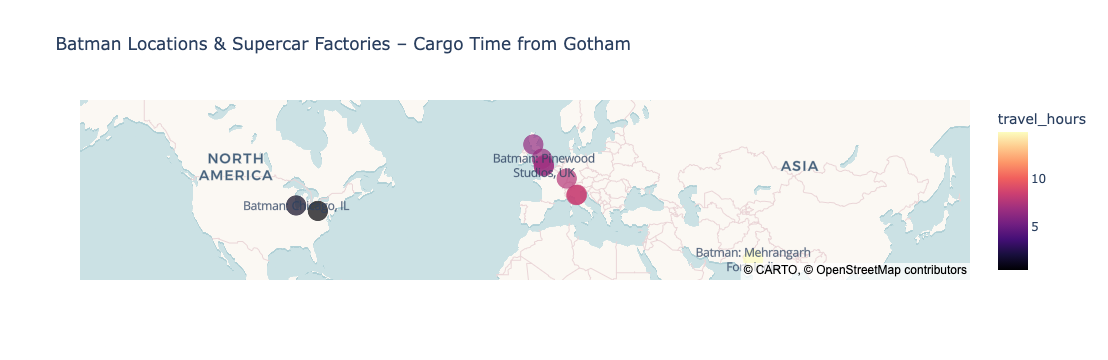